# Modelo preditivo · Risco de defasagem escolar (Passos Mágicos)

**Pergunta 9 do Datathon:** *quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho
ou aumento da defasagem? Construa um modelo que mostre a probabilidade de o aluno entrar em risco de defasagem.*

### Como enquadramos o problema
| Item | Definição |
|---|---|
| **Unidade** | um aluno em um ano *t* (indicadores conhecidos no fim do ano *t*) |
| **Alvo** | `em_defasagem_prox` = 1 se, em *t+1*, o aluno estiver com fase menor que a fase ideal (IAN < 10) |
| **Dados** | pares aluno-ano 2022→2023 e 2023→2024 (alunos que aparecem em anos consecutivos) |
| **Horizonte** | 1 ano à frente, ou seja, há tempo para intervir |
| **Uso** | ordenar alunos por risco e priorizar o acompanhamento psicopedagógico |

**Etapas:** feature engineering → separação treino/teste → modelagem → avaliação → interpretação → exportação para o app Streamlit.

> **Cuidado metodológico:** o mesmo aluno pode aparecer em dois pares (22→23 e 23→24). Para não vazar informação entre treino e teste,
> **todas as separações são agrupadas por aluno (RA)**.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, cross_val_predict
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss, roc_curve,
                             precision_recall_curve, confusion_matrix, classification_report)

warnings.filterwarnings("ignore")
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(RAIZ))
from src.features import prepara_features, FEATURES, BASE, ENGENHARIA, ALVO, faixa_risco

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": .3, "figure.dpi": 110})
NAVY, TEAL, AMBER, CORAL, GRAY = "#0B1F3A", "#0E7C86", "#F2A900", "#D1495B", "#8A94A6"
SEED = 42

## 1. Dados: pares aluno em *t* → situação em *t+1*

In [2]:
pares = pd.read_csv(RAIZ / "data/processed/pares_modelo.csv")
print("pares:", pares.shape, "| alunos distintos:", pares.ra.nunique())
resumo = pares.groupby("ano_base").agg(pares=("ra", "count"), taxa_defasagem_t=("em_defasagem", "mean"),
                                       taxa_defasagem_t1=(ALVO, "mean"), ipp_disponivel=("ipp", lambda s: s.notna().mean())).round(3)
resumo

pares: (1306, 38) | alunos distintos: 855


,pares,taxa_defasagem_t,taxa_defasagem_t1,ipp_disponivel
ano_base,,,,
2022,600,0.685,0.610,0.000
2023,706,0.559,0.436,0.982


A base tem **1.306 pares** (600 de 2022→2023 e 706 de 2023→2024). O alvo é balanceado (~52% em defasagem no ano seguinte),
então **AUC e PR-AUC são métricas adequadas** e não precisamos de reamostragem.
O IPP não existe em 2022; o modelo aceita valores ausentes (gradient boosting trata `NaN` nativamente), o que também permite usar o app sem IPP.

## 2. Feature engineering

Partimos dos 6 indicadores (IDA, IEG, IAA, IPS, IPV, IPP) e de 3 atributos do aluno (defasagem atual, fase, idade), e criamos:

- **`idade_relativa`** = idade − (fase + 7): quanto o aluno é mais velho que o esperado para a fase. Capta atraso escolar acumulado.
- **`gap_autoaval`** = IAA − IDA: excesso de autoconfiança (Pergunta 4).

Testamos ainda média dos indicadores, mínimo, interação IDA×IEG, tempo no programa, instituição e gênero (tabela na seção 4).
**Nenhuma delas melhorou o modelo de forma relevante** (ganho de AUC ≤ 0,004, dentro do ruído da validação); por isso ficaram de fora. Gênero foi excluído também por razão ética: não queremos que a ferramenta
use gênero para priorizar (ou deixar de priorizar) alunos.

In [3]:
X = prepara_features(pares)
y = pares[ALVO].astype(int)
grupos = pares.ra
print(X.shape, "| features:", FEATURES)
X.describe().T[["count", "mean", "std", "min", "max"]].round(2)

(1306, 11) | features: ['ida', 'ieg', 'iaa', 'ips', 'ipv', 'ipp', 'defasagem', 'fase', 'idade', 'idade_relativa', 'gap_autoaval']


,count,mean,std,min,max
ida,1293.0,6.66,1.69,1.00,10.00
ieg,1293.0,8.60,1.20,2.00,10.00
iaa,1306.0,7.66,2.99,0.00,10.00
ips,1303.0,5.96,1.91,2.50,10.00
ipv,1293.0,7.81,1.01,3.32,10.01
ipp,693.0,7.62,0.98,4.38,9.79
defasagem,1306.0,-0.76,0.82,-4.00,2.00
fase,1306.0,2.01,1.79,0.00,7.00
idade,1306.0,11.75,2.69,7.00,22.00
idade_relativa,1306.0,2.75,1.30,0.00,8.00


## 3. Separação treino / teste (agrupada por aluno)

In [4]:
cv_split = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=SEED)
idx_tr, idx_te = next(cv_split.split(X, y, grupos))
X_tr, X_te, y_tr, y_te = X.iloc[idx_tr], X.iloc[idx_te], y.iloc[idx_tr], y.iloc[idx_te]
g_tr = grupos.iloc[idx_tr]
assert set(grupos.iloc[idx_tr]).isdisjoint(set(grupos.iloc[idx_te])), "vazamento: mesmo aluno em treino e teste"
print(f"treino: {len(X_tr)} pares ({y_tr.mean():.1%} em defasagem) | teste: {len(X_te)} pares ({y_te.mean():.1%} em defasagem)")

treino: 978 pares (51.5% em defasagem) | teste: 328 pares (51.8% em defasagem)


## 4. Modelagem
Comparamos, **apenas dentro do treino** (validação cruzada agrupada, 5 dobras × 3 repetições), uma regra de negócio simples e três famílias de modelos.
A regra de referência é *"quem está defasado hoje continuará defasado"*.

In [5]:
def cv_grupos(X_, y_, g_, seed):
    return list(StratifiedGroupKFold(5, shuffle=True, random_state=seed).split(X_, y_, g_))

def avalia_cv(modelo, cols=FEATURES, repet=(1, 2, 3)):
    r = []
    for s in repet:
        p = np.zeros(len(X_tr))
        for a, b in cv_grupos(X_tr, y_tr, g_tr, s):
            m = modelo().fit(X_tr.iloc[a][cols], y_tr.iloc[a]); p[b] = m.predict_proba(X_tr.iloc[b][cols])[:, 1]
        r.append((roc_auc_score(y_tr, p), average_precision_score(y_tr, p), brier_score_loss(y_tr, p)))
    return np.mean(r, axis=0)

modelos = {
    "Regressão logística": lambda: make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler(), LogisticRegression(C=.5, max_iter=3000)),
    "Random Forest":       lambda: make_pipeline(SimpleImputer(strategy="median", add_indicator=True), RandomForestClassifier(400, min_samples_leaf=5, random_state=SEED, n_jobs=-1)),
    "Gradient Boosting":   lambda: HistGradientBoostingClassifier(max_depth=2, learning_rate=.05, max_iter=250, l2_regularization=1, random_state=SEED),
}
linhas = [{"modelo": "Regra: continua defasado", "AUC": roc_auc_score(y_tr, X_tr.defasagem.lt(0).astype(float)),
           "PR-AUC": average_precision_score(y_tr, X_tr.defasagem.lt(0).astype(float)), "Brier": np.nan}]
for nome, mk in modelos.items():
    a, p, b = avalia_cv(mk); linhas.append({"modelo": nome, "AUC": a, "PR-AUC": p, "Brier": b})
tab_modelos = pd.DataFrame(linhas).set_index("modelo").round(3)
tab_modelos

,AUC,PR-AUC,Brier
modelo,,,
Regra: continua defasado,0.668,0.622,NaN
Regressão logística,0.844,0.851,0.161
Random Forest,0.897,0.889,0.132
Gradient Boosting,0.892,0.889,0.132


**Leitura:** os modelos de árvores entregam AUC ≈ 0,89–0,90 contra 0,67 da regra de persistência, e a regressão logística fica em ≈ 0,84. Random Forest e Gradient Boosting empatam estatisticamente; escolhemos o **Gradient Boosting** por aceitar valores ausentes nativamente (IPP não existe em 2022 e pode faltar no app), ser mais leve e calibrar bem.

In [6]:
# Ablação de variáveis (gradient boosting, mesmas dobras): o que realmente agrega?
mk = modelos["Gradient Boosting"]
X_all = X_tr.copy()
X_all["media_ind"] = X_all[["ida", "ieg", "iaa", "ips", "ipv", "ipp"]].mean(axis=1)
X_all["min_ind"]   = X_all[["ida", "ieg", "ipv"]].min(axis=1)
X_all["ida_x_ieg"] = X_all.ida * X_all.ieg / 10
X_all["tempo_programa"] = pares.iloc[idx_tr].tempo_programa.values
X_all["instituicao_publica"] = (pares.iloc[idx_tr].instituicao.values == "Pública").astype(int)
X_all["genero_fem"] = (pares.iloc[idx_tr].genero.values == "Feminino").astype(int)

def cv_extra(cols):
    r = []
    for s in (1, 2, 3):
        p = np.zeros(len(X_all))
        for a, b in cv_grupos(X_all, y_tr, g_tr, s):
            m = mk().fit(X_all.iloc[a][cols], y_tr.iloc[a]); p[b] = m.predict_proba(X_all.iloc[b][cols])[:, 1]
        r.append(roc_auc_score(y_tr, p))
    return np.mean(r)

estrut = ["defasagem", "fase", "idade", "idade_relativa"]
indic = ["ida", "ieg", "iaa", "ips", "ipv", "ipp"]
ablacao = pd.Series({
    "Só variáveis estruturais (defasagem, fase, idade)": cv_extra(estrut),
    "Só indicadores (IDA, IEG, IAA, IPS, IPV, IPP)": cv_extra(indic),
    "Modelo escolhido (estruturais + indicadores + engenharia)": cv_extra(FEATURES),
    "  + média/mínimo dos indicadores e IDA×IEG": cv_extra(FEATURES + ["media_ind", "min_ind", "ida_x_ieg"]),
    "  + tempo no programa": cv_extra(FEATURES + ["tempo_programa"]),
    "  + instituição pública/privada": cv_extra(FEATURES + ["instituicao_publica"]),
    "  + gênero": cv_extra(FEATURES + ["genero_fem"]),
    "Modelo escolhido sem IPP": cv_extra([c for c in FEATURES if c not in ("ipp", "gap_autoaval")]),
}, name="AUC (CV no treino)").round(3)
ablacao.to_frame()

,AUC (CV no treino)
"Só variáveis estruturais (defasagem, fase, idade)",0.855
"Só indicadores (IDA, IEG, IAA, IPS, IPV, IPP)",0.760
Modelo escolhido (estruturais + indicadores + engenharia),0.892
+ média/mínimo dos indicadores e IDA×IEG,0.893
+ tempo no programa,0.896
+ instituição pública/privada,0.892
+ gênero,0.893
Modelo escolhido sem IPP,0.892


**Leitura da ablação (achado importante):** as variáveis **estruturais** (onde o aluno está e que idade tem) já dão AUC ≈ 0,86: defasagem é muito persistente.
Os **indicadores pedagógicos sozinhos** chegam a ≈ 0,76, e **somados** elevam o modelo para ≈ 0,89. Ou seja, os indicadores acrescentam poder de discriminação
além do que a idade e a fase já mostram. Variáveis extras têm ganho desprezível (≤ 0,004 de AUC) e ficaram de fora.

### Ajuste de hiperparâmetros (busca em grade, CV agrupada só no treino)

In [7]:
grade = {"max_depth": [2, 3], "learning_rate": [.03, .06], "max_iter": [150, 300], "l2_regularization": [0, 2], "min_samples_leaf": [20, 40]}
busca = GridSearchCV(HistGradientBoostingClassifier(random_state=SEED), grade, scoring="roc_auc",
                     cv=cv_grupos(X_tr, y_tr, g_tr, 7), n_jobs=-1).fit(X_tr, y_tr)
print("melhores parâmetros:", busca.best_params_, "| AUC CV:", round(busca.best_score_, 3))
melhor = busca.best_params_

melhores parâmetros: {'l2_regularization': 2, 'learning_rate': 0.06, 'max_depth': 2, 'max_iter': 300, 'min_samples_leaf': 20} | AUC CV: 0.896


### Calibração das probabilidades

O app mostra **probabilidades**, então elas precisam ser confiáveis ("70% de risco" deve significar ~70% de casos). Calibramos por regressão sigmoide (Platt) com validação agrupada.

In [8]:
base = HistGradientBoostingClassifier(random_state=SEED, **melhor)
modelo = CalibratedClassifierCV(base, method="sigmoid", cv=cv_grupos(X_tr, y_tr, g_tr, 11)).fit(X_tr, y_tr)
p_te = modelo.predict_proba(X_te)[:, 1]
p_bruto = HistGradientBoostingClassifier(random_state=SEED, **melhor).fit(X_tr, y_tr).predict_proba(X_te)[:, 1]
print("Brier sem calibrar:", round(brier_score_loss(y_te, p_bruto), 4), "| calibrado:", round(brier_score_loss(y_te, p_te), 4))

Brier sem calibrar: 0.1283 | calibrado: 0.1259


## 5. Avaliação no conjunto de teste (nunca visto)

In [9]:
auc, ap, brier = roc_auc_score(y_te, p_te), average_precision_score(y_te, p_te), brier_score_loss(y_te, p_te)
base_te = X_te.defasagem.lt(0).astype(float)
print(f"AUC {auc:.3f} | PR-AUC {ap:.3f} | Brier {brier:.3f}   (regra 'continua defasado': AUC {roc_auc_score(y_te, base_te):.3f}, PR-AUC {average_precision_score(y_te, base_te):.3f})")

pred = (p_te >= .5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()
print(f"\nLimiar 0,50 → acurácia {(tp+tn)/len(y_te):.1%} | precisão {tp/(tp+fp):.1%} | recall {tp/(tp+fn):.1%} | especificidade {tn/(tn+fp):.1%}")
print(classification_report(y_te, pred, target_names=["não defasado em t+1", "defasado em t+1"], digits=3))
pd.DataFrame([[tn, fp], [fn, tp]], index=["real: não defasado", "real: defasado"], columns=["previsto: não", "previsto: sim"])

AUC 0.904 | PR-AUC 0.912 | Brier 0.126   (regra 'continua defasado': AUC 0.696, PR-AUC 0.644)

Limiar 0,50 → acurácia 82.9% | precisão 82.8% | recall 84.7% | especificidade 81.0%
                     precision    recall  f1-score   support

não defasado em t+1      0.831     0.810     0.821       158
    defasado em t+1      0.828     0.847     0.837       170

           accuracy                          0.829       328
          macro avg      0.829     0.829     0.829       328
       weighted avg      0.829     0.829     0.829       328



,previsto: não,previsto: sim
real: não defasado,128,30
real: defasado,26,144


In [10]:
# Faixas de risco usadas no app: a taxa observada em cada faixa deve crescer e acompanhar a probabilidade prevista
teste = pd.DataFrame({"p": p_te, "y": y_te.values, "defasagem_hoje": X_te.defasagem.values})
teste["faixa"] = teste.p.map(faixa_risco)
faixas = teste.groupby("faixa").agg(alunos=("y", "size"), prob_media_prevista=("p", "mean"), taxa_real_defasagem=("y", "mean")).reindex(["Baixo", "Médio", "Alto"]).round(3)
faixas["% dos alunos"] = (faixas.alunos / len(teste) * 100).round(1)
faixas

,alunos,prob_media_prevista,taxa_real_defasagem,% dos alunos
faixa,,,,
Baixo,122,0.128,0.115,37.2
Médio,73,0.513,0.521,22.3
Alto,133,0.856,0.887,40.5


In [11]:
# Alunos que HOJE estão adequados: quem vai cair em defasagem? (o caso mais valioso para prevenção)
ok = teste.defasagem_hoje >= 0
print(f"Adequados hoje no teste: {ok.sum()} | entram em defasagem: {teste.y[ok].mean():.1%} | AUC do modelo nesse subgrupo: {roc_auc_score(teste.y[ok], teste.p[ok]):.3f}")
top = teste[ok].sort_values("p", ascending=False).head(int(ok.sum() * .3))
print(f"Se acompanharmos os 30% de maior risco entre os adequados, capturamos {top.y.sum() / teste.y[ok].sum():.0%} dos que entrarão em defasagem (acaso: 30%).")

Adequados hoje no teste: 114 | entram em defasagem: 23.7% | AUC do modelo nesse subgrupo: 0.873
Se acompanharmos os 30% de maior risco entre os adequados, capturamos 74% dos que entrarão em defasagem (acaso: 30%).


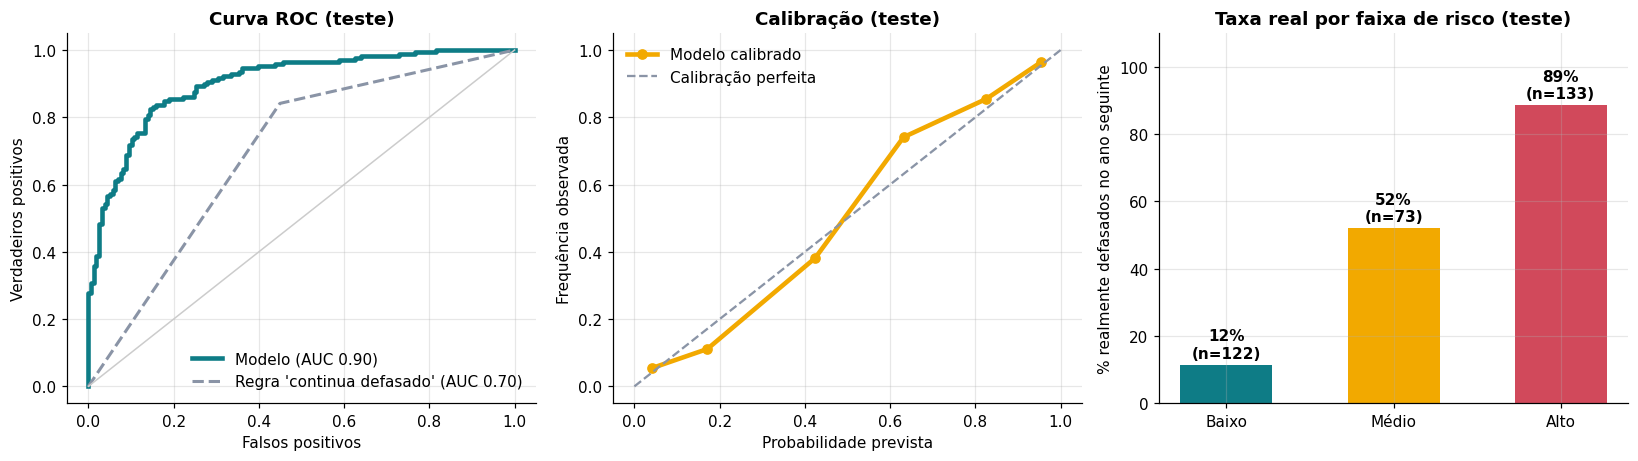

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
fpr, tpr, _ = roc_curve(y_te, p_te); fb, tb, _ = roc_curve(y_te, base_te)
ax[0].plot(fpr, tpr, color=TEAL, lw=3, label=f"Modelo (AUC {auc:.2f})"); ax[0].plot(fb, tb, color=GRAY, lw=2, ls="--", label=f"Regra 'continua defasado' (AUC {roc_auc_score(y_te, base_te):.2f})")
ax[0].plot([0, 1], [0, 1], color="#ccc", lw=1); ax[0].set_xlabel("Falsos positivos"); ax[0].set_ylabel("Verdadeiros positivos"); ax[0].set_title("Curva ROC (teste)", fontweight="bold"); ax[0].legend(frameon=False, loc="lower right")
fr, mp = calibration_curve(y_te, p_te, n_bins=6, strategy="quantile")
ax[1].plot(mp, fr, marker="o", color=AMBER, lw=3, label="Modelo calibrado"); ax[1].plot([0, 1], [0, 1], color=GRAY, ls="--", label="Calibração perfeita")
ax[1].set_xlabel("Probabilidade prevista"); ax[1].set_ylabel("Frequência observada"); ax[1].set_title("Calibração (teste)", fontweight="bold"); ax[1].legend(frameon=False)
cores = {"Baixo": TEAL, "Médio": AMBER, "Alto": CORAL}
ax[2].bar(faixas.index, faixas.taxa_real_defasagem * 100, color=[cores[i] for i in faixas.index], width=.55)
for i, (t, n) in enumerate(zip(faixas.taxa_real_defasagem, faixas.alunos)):
    ax[2].text(i, t * 100 + 2, f"{t:.0%}\n(n={n})", ha="center", fontweight="bold")
ax[2].set_ylim(0, 110); ax[2].set_ylabel("% realmente defasados no ano seguinte"); ax[2].set_title("Taxa real por faixa de risco (teste)", fontweight="bold")
plt.tight_layout(); plt.savefig(RAIZ / "reports/figuras/q9_modelo_avaliacao.png", dpi=200, bbox_inches="tight", facecolor="white"); plt.show()

## 6. Robustez: validação temporal

Treinamos só com pares 2022→2023 e testamos em 2023→2024. É o teste mais próximo do uso real (prever um ano que ainda não aconteceu).

In [13]:
tr_t, te_t = (pares.ano_base == 2022).values, (pares.ano_base == 2023).values
m_t = CalibratedClassifierCV(HistGradientBoostingClassifier(random_state=SEED, **melhor), method="sigmoid",
                             cv=cv_grupos(X[tr_t], y[tr_t], grupos[tr_t], 5)).fit(X[tr_t], y[tr_t])
p_t = m_t.predict_proba(X[te_t])[:, 1]
auc_temporal = roc_auc_score(y[te_t], p_t)
print(f"Treino 2022→2023 ({tr_t.sum()}) · Teste 2023→2024 ({te_t.sum()}): AUC {auc_temporal:.3f} | PR-AUC {average_precision_score(y[te_t], p_t):.3f} | Brier {brier_score_loss(y[te_t], p_t):.3f}")

Treino 2022→2023 (600) · Teste 2023→2024 (706): AUC 0.879 | PR-AUC 0.851 | Brier 0.143


## 7. Interpretação: o que o modelo usa?

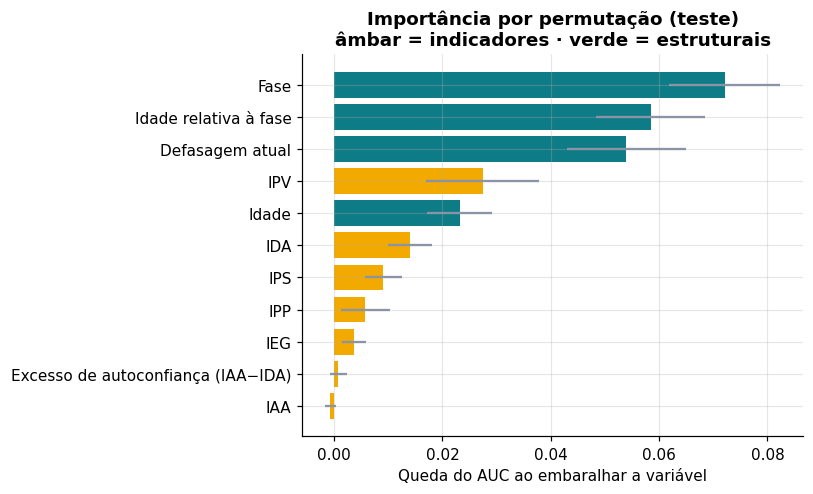

,queda de AUC
fase,0.072
idade_relativa,0.058
defasagem,0.054
ipv,0.027
idade,0.023
ida,0.014
ips,0.009
ipp,0.006
ieg,0.004
gap_autoaval,0.001


In [14]:
pi = permutation_importance(modelo, X_te, y_te, scoring="roc_auc", n_repeats=30, random_state=SEED)
imp = pd.Series(pi.importances_mean, index=FEATURES).sort_values()
nomes = {"fase": "Fase", "defasagem": "Defasagem atual", "idade": "Idade", "idade_relativa": "Idade relativa à fase", "ipv": "IPV", "ida": "IDA", "ieg": "IEG",
         "ipp": "IPP", "ips": "IPS", "iaa": "IAA", "gap_autoaval": "Excesso de autoconfiança (IAA−IDA)"}
fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.barh([nomes[i] for i in imp.index], imp.values, xerr=pi.importances_std[[FEATURES.index(i) for i in imp.index]],
        color=[AMBER if i in ("ipv", "ida", "ieg", "ipp", "ips", "iaa", "gap_autoaval") else TEAL for i in imp.index], error_kw={"ecolor": GRAY})
ax.set_xlabel("Queda do AUC ao embaralhar a variável"); ax.set_title("Importância por permutação (teste)\nâmbar = indicadores · verde = estruturais", fontweight="bold")
plt.tight_layout(); plt.savefig(RAIZ / "reports/figuras/q9_importancia.png", dpi=200, bbox_inches="tight", facecolor="white"); plt.show()
imp.sort_values(ascending=False).round(3).to_frame("queda de AUC")

**Como ler:** *fase*, *idade relativa* e *defasagem atual* são os principais sinais (defasagem é persistente). Entre os indicadores pedagógicos, **IPV e IDA** são os que mais pesam; IEG, IPS e IPP têm importância individual menor porque
são correlacionados com IDA e IPV (o modelo "divide o crédito"). A importância por permutação descreve **associação, não causa**.

## 8. Modelo final e exportação

Após validar, o modelo final é **treinado com todos os pares** (mais dados = melhor estimativa) usando os hiperparâmetros escolhidos. As métricas reportadas ao usuário são as do teste da seção 5.

In [15]:
modelo_final = CalibratedClassifierCV(HistGradientBoostingClassifier(random_state=SEED, **melhor), method="sigmoid",
                                      cv=cv_grupos(X, y, grupos, 21)).fit(X, y)
(RAIZ / "models").mkdir(exist_ok=True)
joblib.dump(modelo_final, RAIZ / "models/modelo_risco.joblib")

meta = {
    "alvo": "Aluno em defasagem (fase < fase ideal) no ano seguinte",
    "features": FEATURES,
    "n_pares": int(len(X)), "n_alunos": int(pares.ra.nunique()), "n_treino": int(len(X_tr)), "n_teste": int(len(X_te)),
    "prevalencia_alvo": round(float(y.mean()), 3),
    "hiperparametros": {k: (float(v) if isinstance(v, float) else int(v)) for k, v in melhor.items()},
    "metricas_teste": {"auc": round(auc, 3), "pr_auc": round(ap, 3), "brier": round(brier, 3), "acuracia_limiar_050": round((tp + tn) / len(y_te), 3),
                       "precisao_limiar_050": round(tp / (tp + fp), 3), "recall_limiar_050": round(tp / (tp + fn), 3)},
    "baseline_persistencia": {"auc": round(roc_auc_score(y_te, base_te), 3), "pr_auc": round(average_precision_score(y_te, base_te), 3)},
    "validacao_temporal_auc": round(auc_temporal, 3),
    "comparacao_cv_treino": tab_modelos.reset_index().astype(object).where(tab_modelos.reset_index().notna(), None).to_dict("records"),
    "ablacao_auc": ablacao.to_dict(),
    "faixas_risco": {k: {kk: float(vv) for kk, vv in v.items()} for k, v in faixas.drop(columns="% dos alunos").to_dict("index").items()},
    "adequados_hoje": {"taxa_entram_defasagem": round(float(teste.y[ok].mean()), 3), "auc": round(float(roc_auc_score(teste.y[ok], teste.p[ok])), 3),
                       "captura_top30": round(float(top.y.sum() / teste.y[ok].sum()), 3)},
    "importancia_permutacao": imp.sort_values(ascending=False).round(4).to_dict(),
    "referencia_medianas": {c: float(X[c].median()) for c in FEATURES if c not in ("idade_relativa", "gap_autoaval")},
}
(RAIZ / "models/metadata.json").write_text(json.dumps(meta, ensure_ascii=False, indent=1))
print("modelo e metadados salvos em models/")

modelo e metadados salvos em models/


## 9. Exemplo de uso

In [16]:
aluno = pd.DataFrame([{"ida": 6.0, "ieg": 7.5, "iaa": 8.5, "ips": 7.5, "ipv": 6.8, "ipp": 7.5, "defasagem": 0, "fase": 3, "idade": 14}])
p = modelo_final.predict_proba(prepara_features(aluno))[0, 1]
print(f"Probabilidade de estar em defasagem no próximo ano: {p:.1%} → risco {faixa_risco(p)}")

Probabilidade de estar em defasagem no próximo ano: 64.0% → risco Médio
